In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('House Price India (1).csv')

df.head()

Saving House Price India.csv to House Price India (2).csv


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [ ]:
df.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

## Q1. What is the average, median, and standard deviation of house prices?

In [ ]:
avg_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

print("Average Price:", avg_price)
print("Median Price:", median_price)
print("Standard Deviation:", std_price)

Average Price: 538932.2183310534
Median Price: 450000.0
Standard Deviation: 367532.3808039669


### Visualization

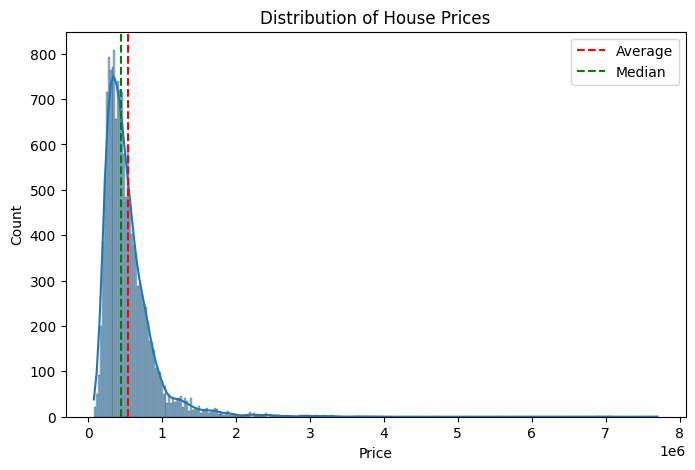

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.axvline(avg_price, color='red', linestyle='--', label='Average')
plt.axvline(median_price, color='green', linestyle='--', label='Median')
plt.title("Distribution of House Prices")
plt.legend()
plt.show()

### Detailed Interpretation
The average house price represents the mean market price of all houses in the dataset.
The median price represents the middle value and is useful because it is less affected by extremely expensive properties.
The standard deviation indicates how spread out house prices are from the average.
A high standard deviation suggests that the dataset contains houses across multiple price segments, ranging from affordable to luxury properties.

## Q2. Which number of bedrooms is most common?

In [ ]:
most_common_bedrooms = df['number of bedrooms'].mode()[0]
print("Most Common Bedrooms:", most_common_bedrooms)

Most Common Bedrooms: 3


### Visualization

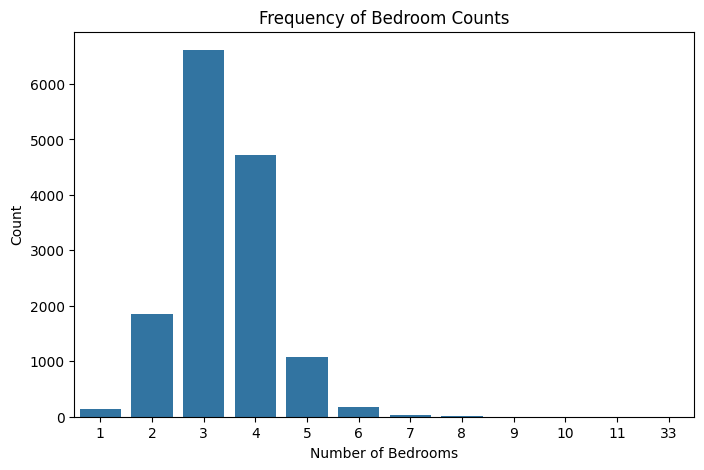

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='number of bedrooms', data=df)
plt.title("Frequency of Bedroom Counts")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")
plt.show()

### Detailed Interpretation
The mode identifies the most frequently occurring number of bedrooms in the dataset.
This helps determine the most popular house configuration among buyers.
A concentration around a specific bedroom count suggests market demand is strongest for that segment.

## Q3. Check if the price data is skewed.

In [ ]:
skewness = df['Price'].skew()
print("Skewness:", skewness)

Skewness: 4.269297720707116


### Visualization

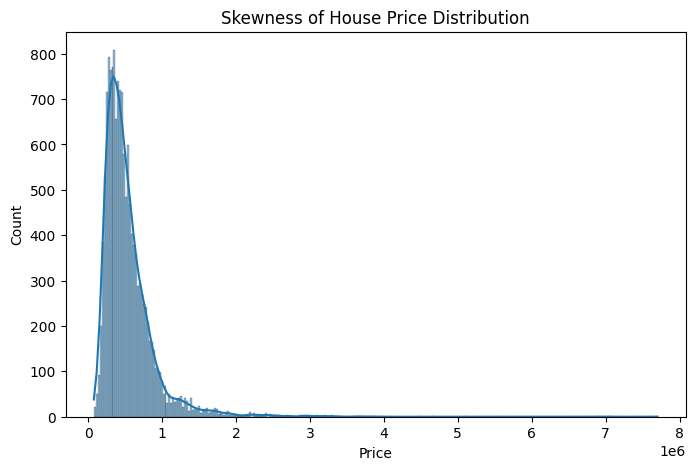

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title("Skewness of House Price Distribution")
plt.show()

### Detailed Interpretation
Skewness measures the asymmetry of the price distribution.
If skewness is positive, the distribution is right-skewed, meaning a small number of luxury properties significantly increase the average price.
If skewness is close to zero, the prices are normally distributed.
A highly skewed distribution suggests presence of outliers in premium market segments.

## Q4. What is the average price for each number of bedrooms?

In [ ]:
bedroom_price = df.groupby('number of bedrooms')['Price'].mean()
print(bedroom_price)

number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: Price, dtype: float64


### Visualization

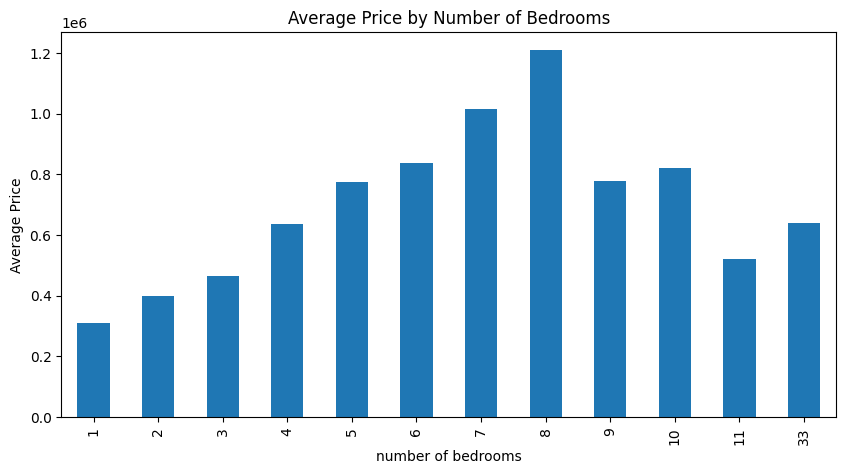

In [ ]:
plt.figure(figsize=(10,5))
bedroom_price.plot(kind='bar')
plt.title("Average Price by Number of Bedrooms")
plt.ylabel("Average Price")
plt.show()

### Detailed Interpretation
This analysis shows how pricing changes with bedroom count.
Generally, houses with more bedrooms have higher average prices because they offer more usable space and target larger families.
However, irregularities may occur if luxury small-bedroom homes exist in premium locations.

## Q5. What is the relationship between living area and price?

In [ ]:
correlation = df['Area of the house(excluding basement)'].corr(df['Price'])
print("Correlation:", correlation)

Correlation: 0.6152204198678108


### Visualization

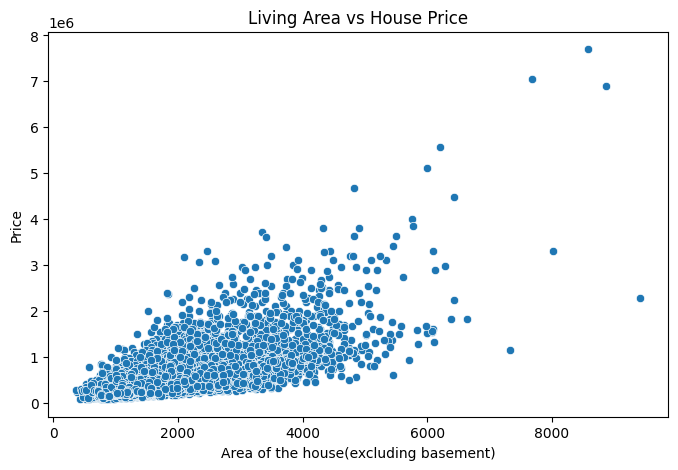

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Area of the house(excluding basement)',
    y='Price',
    data=df
)
plt.title("Living Area vs House Price")
plt.show()

### Detailed Interpretation
The scatter plot and correlation value help evaluate the relationship between house size and price.
A positive correlation indicates that larger houses generally command higher prices.
If the correlation is strong, area is a major pricing factor in this market.

## Q6. Identify anomalies where houses have high prices but low areas.


In [ ]:
anomalies = df[
    (df['Price'] > df['Price'].quantile(0.90)) &
    (df['Area of the house(excluding basement)'] < df['Area of the house(excluding basement)'].quantile(0.25))
]

anomalies[['Price','Area of the house(excluding basement)']].head()

,Price,Area of the house(excluding basement)
1125,970000,1130
1210,1180000,1090
1517,1180000,1100
2154,1150000,1130
8517,990000,930


### Visualization

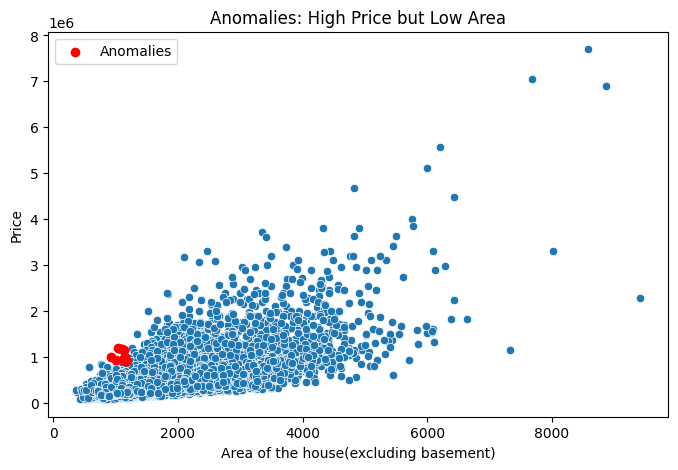

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Area of the house(excluding basement)',
    y='Price',
    data=df
)

plt.scatter(
    anomalies['Area of the house(excluding basement)'],
    anomalies['Price'],
    color='red',
    label='Anomalies'
)

plt.legend()
plt.title("Anomalies: High Price but Low Area")
plt.show()

### Detailed Interpretation
These properties appear unusual because they have relatively small living areas but exceptionally high prices.
Possible reasons include:
- Premium location
- Waterfront access
- Luxury interiors
- Strong neighborhood reputation
- Commercial/resale premium

## Q7. Compare average price based on number of floors and waterfront presence.

In [ ]:
floor_price = df.groupby('number of floors')['Price'].mean()
waterfront_price = df.groupby('waterfront present')['Price'].mean()

print(floor_price)
print(waterfront_price)

number of floors
1.0    4.369769e+05
1.5    5.549301e+05
2.0    6.487372e+05
2.5    1.106233e+06
3.0    5.663281e+05
3.5    1.205875e+06
Name: Price, dtype: float64
waterfront present
0    5.304174e+05
1    1.641902e+06
Name: Price, dtype: float64


### Visualization

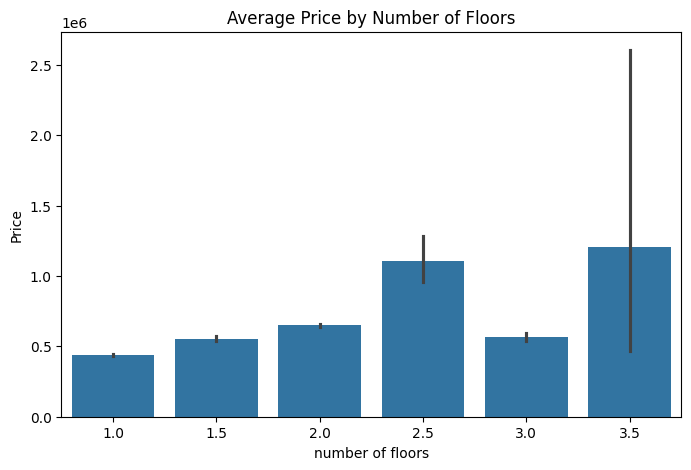

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='number of floors', y='Price', data=df)
plt.title("Average Price by Number of Floors")
plt.show()

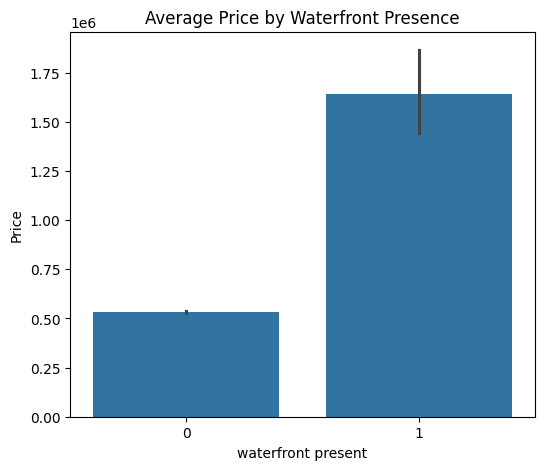

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x='waterfront present', y='Price', data=df)
plt.title("Average Price by Waterfront Presence")
plt.show()

### Detailed Interpretation
Properties with more floors often have larger built-up area and may be priced higher.
Waterfront homes generally command a premium due to superior location and scenic value.
A large pricing difference indicates waterfront is a major luxury factor.

## Q8. Identify minimum and maximum house price. What does this indicate?

In [ ]:
print("Minimum Price:", df['Price'].min())
print("Maximum Price:", df['Price'].max())

Minimum Price: 78000
Maximum Price: 7700000


### Visualization

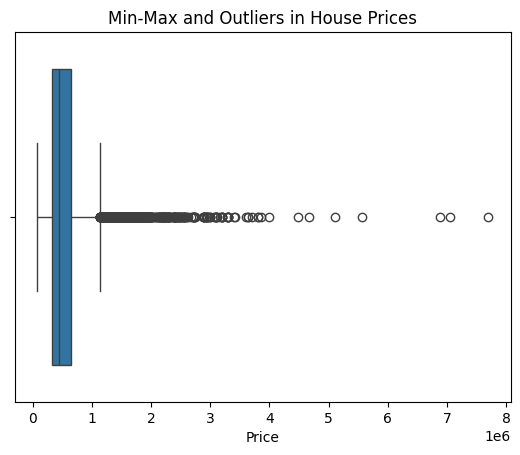

In [ ]:
sns.boxplot(x=df['Price'])
plt.title("Min-Max and Outliers in House Prices")
plt.show()

### Detailed Interpretation
The wide difference between minimum and maximum house price indicates strong market segmentation.
This suggests the dataset includes both affordable and premium/luxury housing categories.
Outliers may represent ultra-premium properties.

## Q9. Which location (Postal Code) has the highest average price?

In [ ]:
location_price = df.groupby('Postal Code')['Price'].mean().sort_values(ascending=False)
print(location_price.head())

Postal Code
122071    2.348311e+06
122048    1.296414e+06
122057    1.188517e+06
122047    1.069295e+06
122061    8.895896e+05
Name: Price, dtype: float64


### Visualization

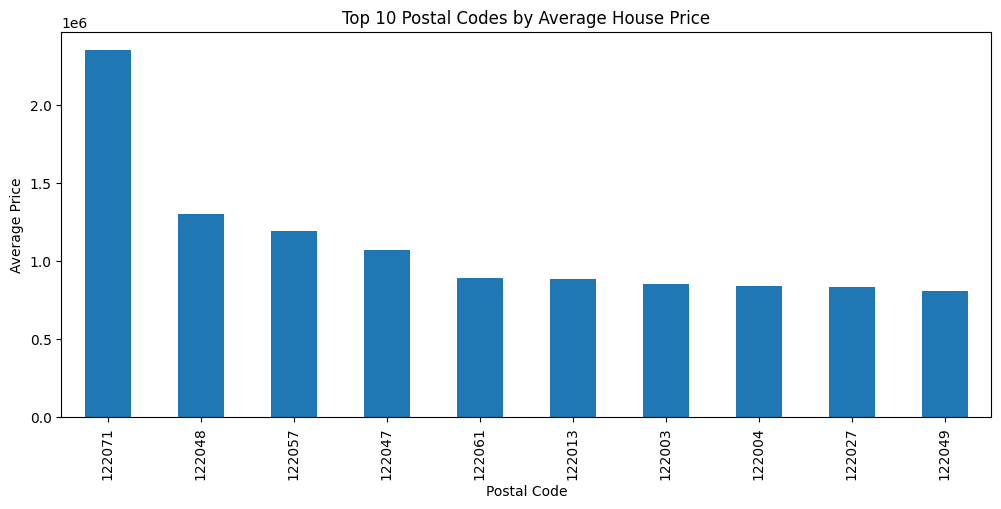

In [ ]:
plt.figure(figsize=(12,5))
location_price.head(10).plot(kind='bar')
plt.title("Top 10 Postal Codes by Average House Price")
plt.ylabel("Average Price")
plt.show()

### Detailed Interpretation
Postal codes with the highest average prices indicate premium residential locations.
These areas may have better infrastructure, connectivity, safety, and lifestyle amenities.

## Q10. Final Business Insights
1. House prices increase significantly with living area, indicating that property size is a major pricing factor.

2. Most buyers prefer houses with common bedroom counts, showing concentration in mid-sized family homes.

3. Waterfront properties command premium prices compared to non-waterfront homes.

4. Certain postal codes have significantly higher average prices, indicating location-based premium.

5. Price distribution is positively skewed due to presence of luxury properties.

6. Some houses have high prices despite smaller areas, suggesting location/amenities also impact valuation.

7. The market contains affordable, mid-range, and luxury housing segments.